# LAVI Python combined with MNE-Python

This notebook demonstrates how to use the Python version of the LAVI toolbox on data read with MNE-Python, to calculate the rhythmicity profile of a multi-channel dataset and detect bands using ABBA.

Here we load the dataset with MNE-Python and use the package's MNE helper function `prepare_lavi_mne`.

We also compare the outputs between the Python and Matlab versions.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat, savemat

import mne

import pandas as pd
from IPython.display import display, Markdown

# Make the local package importable.
# This works whether the notebook is run from the package root, from examples/,
# or from a parent folder such as /mnt/data.
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd() / "lavi_python", Path("/mnt/data/lavi_python")]
PROJECT_ROOT = None
for candidate in candidates:
    if (candidate / "lavi" / "__init__.py").exists():
        PROJECT_ROOT = candidate.resolve()
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the local LAVI Python package folder.")

sys.path.insert(0, str(PROJECT_ROOT))


from lavi import prepare_lavi_mne, get_ap_of_power, abba, compute_pink_lavi

print("Using LAVI package at:", PROJECT_ROOT)

Using LAVI package at: /home/mc06/Documents/CamCAN/code/lavi/lavi_python_v1


## 1. Locate the FIF data file

In [2]:
LAVI_PATH = PROJECT_ROOT
DATA_PATH = LAVI_PATH / "data"
DATA_FILE = DATA_PATH / "meg_data.fif"

print("Project root:", PROJECT_ROOT)
print("Data file exists:", DATA_FILE.exists())


Project root: /home/mc06/Documents/CamCAN/code/lavi/lavi_python_v1
Data file exists: True


## 2. Load the FIF data file

In [3]:
if not DATA_FILE.exists():
    # This is to generate a smaller dataset for demonstration purposes. In practice, you would use the full dataset.
    LARGE_DATA_FILE = LAVI_PATH / "data" / "meg_preprocessed_data.fif"
    raw = mne.io.read_raw_fif(LARGE_DATA_FILE, preload=False).pick('meg') # Pick only MEG channels
    raw = raw.pick(['MEG0441', 'MEG1241', 'MEG2111']) # Pick 3 random channels for demonstration
    raw.crop(tmax=300)  # Crop to the first 300 seconds for demonstration
    raw.save(DATA_FILE, overwrite=True)

raw = mne.io.read_raw_fif(DATA_FILE, preload=True)
dat = raw.get_data()

# Save the data to a .mat file for use in MATLAB to compare results with the original LAVI implementation. (Optional)
savemat(DATA_PATH / "meg_data.mat", {"dat": dat, "fs": raw.info["sfreq"], "label": raw.ch_names})

print("Number of channels:", len(raw.ch_names))
print("Channel names:", raw.ch_names)
print("Duration (s):", raw.duration)
print("Sampling frequency (Hz):", raw.info["sfreq"])

Opening raw data file /home/mc06/Documents/CamCAN/code/lavi/lavi_python_v1/data/meg_data.fif...
    Range : 18300 ... 108300 =     61.000 ...   361.000 secs
Ready.
Reading 0 ... 90000  =      0.000 ...   300.000 secs...
Number of channels: 3
Channel names: ['MEG0441', 'MEG1241', 'MEG2111']
Duration (s): 300.00333333333333
Sampling frequency (Hz): 300.0


/tmp/ipykernel_620304/2106709505.py:9: RuntimeWarning: This filename (/home/mc06/Documents/CamCAN/code/lavi/lavi_python_v1/data/meg_data.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(DATA_FILE, preload=True)


## 3. Define analysis parameters

In [4]:
foi = 10 ** np.arange(0.5, 1.65 + 1e-12, 0.025)
lag = 1.5          # lag between signal and copy, in cycles; default = 1.5
width = 5          # wavelet width, in cycles; default = 5
pink_reps = 20     # number of pink-noise simulations per channel; default = 20
durs = raw.duration          # duration in seconds of each simulation; default in MATLAB was original duration
max_iterate = 1000 # maximal number of iterations in the pink simulation loop

fsample = raw.info["sfreq"]  # sampling frequency, in Hz

labels = [f"Channel {ch}" for ch in raw.ch_names]

print("Number of frequencies:", len(foi))

Number of frequencies: 47


## 4. Calculate LAVI of the data

In [5]:
cfg = {
    "foi": foi,
    "fs": fsample,
    "lag": lag,
    "width": width,
    "verbose": True,
}
LAVI, cfg_out = prepare_lavi_mne(raw, cfg=cfg)

# Save the results to a .mat file for use in MATLAB to compare results with the original LAVI implementation. (Optional)
savemat(DATA_PATH / "python_lavi_results.mat", {
    "LAVI": LAVI,
    "cfg_out": cfg_out,
})

Running LAVI frequency 1/47 (3.16 Hz)
Running LAVI frequency 2/47 (3.35 Hz)
Running LAVI frequency 3/47 (3.55 Hz)
Running LAVI frequency 4/47 (3.76 Hz)
Running LAVI frequency 5/47 (3.98 Hz)
Running LAVI frequency 6/47 (4.22 Hz)
Running LAVI frequency 7/47 (4.47 Hz)
Running LAVI frequency 8/47 (4.73 Hz)
Running LAVI frequency 9/47 (5.01 Hz)
Running LAVI frequency 10/47 (5.31 Hz)
Running LAVI frequency 11/47 (5.62 Hz)
Running LAVI frequency 12/47 (5.96 Hz)
Running LAVI frequency 13/47 (6.31 Hz)
Running LAVI frequency 14/47 (6.68 Hz)
Running LAVI frequency 15/47 (7.08 Hz)
Running LAVI frequency 16/47 (7.5 Hz)
Running LAVI frequency 17/47 (7.94 Hz)
Running LAVI frequency 18/47 (8.41 Hz)
Running LAVI frequency 19/47 (8.91 Hz)
Running LAVI frequency 20/47 (9.44 Hz)
Running LAVI frequency 21/47 (10 Hz)
Running LAVI frequency 22/47 (10.6 Hz)
Running LAVI frequency 23/47 (11.2 Hz)
Running LAVI frequency 24/47 (11.9 Hz)
Running LAVI frequency 25/47 (12.6 Hz)
Running LAVI frequency 26/47 (13.3 Hz

## 5. Plot LAVI

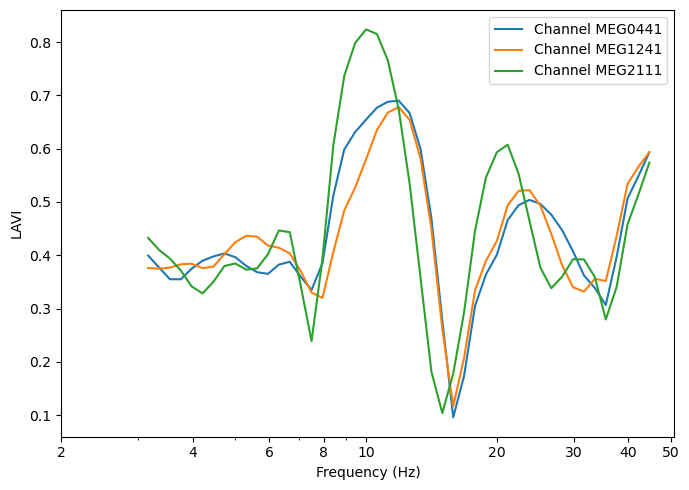

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
for ch in range(LAVI.shape[0]):
    ax.plot(foi, LAVI[ch], label=labels[ch])
ax.set_xscale("log")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("LAVI")
ax.set_xticks(list(range(2, 12, 2)) + list(range(20, int(np.ceil(foi[-1])) + 10, 10)))
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.legend()
fig.tight_layout()
plt.show()

## 6. Genearate pink noise matching the data

In [7]:
RUN_PINK = True  # Set to True to run Option B (pink noise simulation)
pink_reps_quick = 20  # increase to 20 to match the MATLAB default
alpha_range = (6, 14)  # range of alpha values to compute borders

if RUN_PINK:
    cfg_pink = {
        "Pink_reps": pink_reps_quick,
        "durs": durs,
        "foi": foi,
        "fs": fsample,
        "lag": lag,
        "width": width,
        "maxIterate": max_iterate,
        "verbose": True,
    }

    # MATLAB dimord: rep_freq_chan
    PINK = compute_pink_lavi(cfg_pink, dat)

    # MATLAB: pink = permute(PINK,[3,2,1]); dimord: chan_freq_rep
    pink = np.transpose(PINK, (2, 1, 0))

    # MATLAB: sig_lim = cat(3,min(pink,[],3), max(pink,[],3));
    sig_lim = np.stack([np.nanmin(pink, axis=2), np.nanmax(pink, axis=2)], axis=2)

    borders2, col_names2, sigVect2 = abba(
        LAVI,
        foi,
        alpha_range=alpha_range,
        siglim=sig_lim,
        per_freq=False,
    )

    print("PINK shape, rep x freq x chan:", PINK.shape)

    # Save the results to .mat files for use in MATLAB to compare results with the original LAVI implementation. (Optional)
    savemat(DATA_PATH / "python_lavi_pink.mat", {
        "PINK": PINK,
        "sig_lim": sig_lim,
        "cfg_pink": cfg_pink,
        "borders2": borders2,
        "col_names2": col_names2,
        "sigVect2": sigVect2,
    })

    # Save the results to a .mat file for use in MATLAB to compare results with the original LAVI implementation. (Optional)
    savemat(DATA_PATH / "python_lavi_abba_results.mat", {
        "borders2": borders2,
        "col_names2": col_names2,
        "sigVect2": sigVect2,
    })
else:
    PINK = None
    borders2 = None
    sigVect2 = None
    print("Pink-noise simulation skipped. Set RUN_PINK = True to run Option B.")

Running PINK ANALYSIS, Channel 1/3 repeat 1/20 (9 iterations). So far: 0.34 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 2/20 (10 iterations). So far: 2.67 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 3/20 (7 iterations). So far: 4.89 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 4/20 (4 iterations). So far: 7.01 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 5/20 (8 iterations). So far: 9.27 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 6/20 (5 iterations). So far: 11.42 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 7/20 (9 iterations). So far: 13.70 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 8/20 (9 iterations). So far: 15.99 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 9/20 (6 iterations). So far: 18.17 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 10/20 (10 iterations). So far: 20.50 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 11/20 (6 iterations). So far: 22.68 seconds.
Running PINK ANALYSIS, Channel 1/3 repeat 12/20 (17 ite

Run the following to visualize the tables with the band boders definition, for each channel

In [8]:
nCh = len(raw.ch_names)
for ch in range(nCh):
    borders2_df = pd.DataFrame(borders2[ch], columns=col_names2)
    display(Markdown(f"### ABBA Borders for Channel {raw.ch_names[ch]}"))
    display(borders2_df)

### ABBA Borders for Channel MEG0441

,BegI,EndI,PeakI,BegF,EndF,PeakF,PeakLAVI,PeakRel,Dir,Rel_alpha,Sig
0,0.0,0.0,0.0,3.2,3.2,3.2,0.399517,0.001659,1.0,-4.0,1.0
1,1.0,6.0,3.0,3.3,4.5,3.8,0.354967,-0.042891,-1.0,-3.0,0.0
2,7.0,7.0,7.0,4.7,4.7,4.7,0.403358,0.005500,1.0,-2.0,1.0
3,8.0,16.0,15.0,5.0,7.9,7.5,0.334860,-0.062998,-1.0,-1.0,0.0
4,17.0,26.0,23.0,8.4,14.1,11.9,0.689900,0.292041,1.0,0.0,1.0
5,27.0,31.0,28.0,15.0,18.8,15.8,0.096008,-0.301850,-1.0,1.0,1.0
6,32.0,39.0,35.0,20.0,29.9,23.7,0.503898,0.106039,1.0,2.0,1.0
7,40.0,43.0,42.0,31.6,37.6,35.5,0.306645,-0.091214,-1.0,3.0,0.0
8,44.0,46.0,46.0,39.8,44.7,44.7,0.593041,0.195183,1.0,4.0,1.0


### ABBA Borders for Channel MEG1241

,BegI,EndI,PeakI,BegF,EndF,PeakF,PeakLAVI,PeakRel,Dir,Rel_alpha,Sig
0,0.0,7.0,1.0,3.2,4.7,3.3,0.374819,-0.039318,-1.0,-3.0,0.0
1,8.0,12.0,9.0,5.0,6.3,5.3,0.436542,0.022404,1.0,-2.0,1.0
2,13.0,17.0,16.0,6.7,8.4,7.9,0.320192,-0.093945,-1.0,-1.0,0.0
3,18.0,26.0,23.0,8.9,14.1,11.9,0.677938,0.263800,1.0,0.0,1.0
4,27.0,31.0,28.0,15.0,18.8,15.8,0.116751,-0.297386,-1.0,1.0,1.0
5,32.0,37.0,35.0,20.0,26.6,23.7,0.522190,0.108053,1.0,2.0,1.0
6,38.0,42.0,40.0,28.2,35.5,31.6,0.331858,-0.082279,-1.0,3.0,0.0
7,43.0,46.0,46.0,37.6,44.7,44.7,0.593462,0.179325,1.0,4.0,1.0


### ABBA Borders for Channel MEG2111

,BegI,EndI,PeakI,BegF,EndF,PeakF,PeakLAVI,PeakRel,Dir,Rel_alpha,Sig
0,0.0,2.0,0.0,3.2,3.5,3.2,0.432613,0.039184,1.0,-4.0,1.0
1,3.0,10.0,5.0,3.8,5.6,4.2,0.328445,-0.064984,-1.0,-3.0,0.0
2,11.0,13.0,12.0,6.0,6.7,6.3,0.446526,0.053097,1.0,-2.0,1.0
3,14.0,16.0,15.0,7.1,7.9,7.5,0.239037,-0.154392,-1.0,-1.0,0.0
4,17.0,24.0,20.0,8.4,12.6,10.0,0.823656,0.430226,1.0,0.0,1.0
5,25.0,29.0,27.0,13.3,16.8,15.0,0.103901,-0.289528,-1.0,1.0,1.0
6,30.0,35.0,33.0,17.8,23.7,21.1,0.607305,0.213876,1.0,2.0,1.0
7,36.0,43.0,42.0,25.1,37.6,35.5,0.279571,-0.113859,-1.0,3.0,0.0
8,44.0,46.0,46.0,39.8,44.7,44.7,0.573698,0.180268,1.0,4.0,1.0


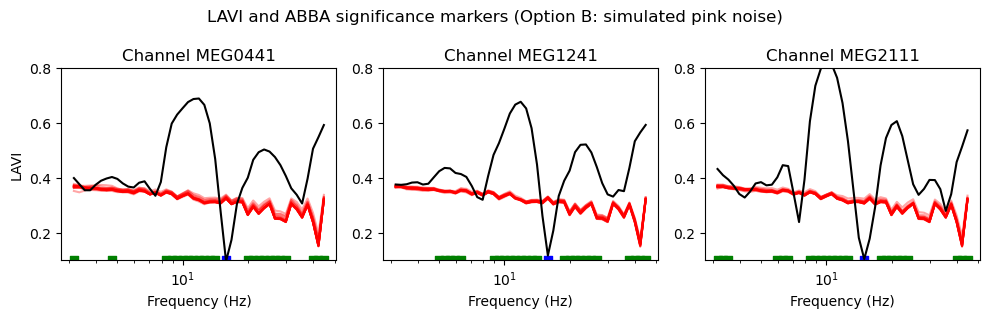

In [9]:
if 'sigVect2' in locals() and sigVect2 is not None:
    sig_to_plot = sigVect2
    title_suffix = "Option B: simulated pink noise"

cols = 3
rows = int(np.ceil(LAVI.shape[0] / cols))
fig, axes = plt.subplots(rows, cols, figsize=(10, 3.2 * rows), squeeze=False)
axes = axes.ravel()

for ch in range(LAVI.shape[0]):
    ax = axes[ch]

    if PINK is not None:
        # PINK has shape rep x freq x chan.
        ax.plot(foi, PINK[:, :, ch].T, alpha=0.35, color='red')

    ax.plot(foi, LAVI[ch], linewidth=1.5, color="black")

    posind = np.asarray(sig_to_plot[ch]) > 0
    negind = np.asarray(sig_to_plot[ch]) < 0

    # Colours are specified here to match the original MATLAB comments.
    ax.scatter(foi[posind], np.ones(np.sum(posind)) * 0.1, marker="s", color="green")
    ax.scatter(foi[negind], np.ones(np.sum(negind)) * 0.1, marker="s", color="blue")

    ax.set_xscale("log")
    ax.set_ylim([0.1, 0.8])
    ax.set_xlabel("Frequency (Hz)")
    if ch % cols == 0:
        ax.set_ylabel("LAVI")
    ax.set_title(labels[ch] if ch < len(labels) else f"Channel {ch + 1}")

for ax in axes[LAVI.shape[0]:]:
    ax.axis("off")

fig.suptitle(f"LAVI and ABBA significance markers ({title_suffix})")
fig.tight_layout()
plt.show()

In [10]:
mat = loadmat(DATA_PATH / "python_lavi_abba_results.mat")
py_borders = mat["borders2"]
mat = loadmat(DATA_PATH / "matlab_lavi_abba_results.mat")
mat_borders = mat["borders2"]


for ch, label in enumerate(raw.ch_names):
    py_df = pd.DataFrame(py_borders[0][ch], columns=col_names2)
    mat_df = pd.DataFrame(mat_borders[0][ch], columns=col_names2)
    diff_df = py_df.subtract(mat_df)

    display(Markdown(f"### Difference between Python and MATLAB ABBA borders for Channel {label}"))
    print("Python borders:", py_df.shape)
    print("MATLAB borders:", mat_df.shape)
    print("Max absolute difference (BegF):", diff_df['BegF'].abs().max().max())
    print("Max absolute difference (EndF):", diff_df['EndF'].abs().max().max())
    print("Max absolute difference (PeakF):", diff_df['PeakF'].abs().max().max())
    print("Max absolute difference (PeakLAVI):", diff_df['PeakLAVI'].abs().max().max())
    print("Max absolute difference (Dir):", diff_df['Dir'].abs().max().max())
    print("Max absolute difference (Rel_alpha):", diff_df['Rel_alpha'].abs().max().max())   


### Difference between Python and MATLAB ABBA borders for Channel MEG0441

Python borders: (9, 11)
MATLAB borders: (9, 11)
Max absolute difference (BegF): 0.0
Max absolute difference (EndF): 0.0
Max absolute difference (PeakF): 0.0
Max absolute difference (PeakLAVI): 1.963054327891456e-05
Max absolute difference (Dir): 0.0
Max absolute difference (Rel_alpha): 0.0


### Difference between Python and MATLAB ABBA borders for Channel MEG1241

Python borders: (8, 11)
MATLAB borders: (8, 11)
Max absolute difference (BegF): 0.0
Max absolute difference (EndF): 0.0
Max absolute difference (PeakF): 0.0
Max absolute difference (PeakLAVI): 1.2247630705064516e-05
Max absolute difference (Dir): 0.0
Max absolute difference (Rel_alpha): 0.0


### Difference between Python and MATLAB ABBA borders for Channel MEG2111

Python borders: (9, 11)
MATLAB borders: (9, 11)
Max absolute difference (BegF): 0.0
Max absolute difference (EndF): 0.0
Max absolute difference (PeakF): 0.0
Max absolute difference (PeakLAVI): 1.571182636600499e-05
Max absolute difference (Dir): 0.0
Max absolute difference (Rel_alpha): 0.0


In [11]:
mat = loadmat(DATA_PATH / "python_lavi_results.mat")
py_LAVI = mat["LAVI"]
mat = loadmat(DATA_PATH / "matlab_lavi_results.mat")
mat_LAVI = mat["LAVI"]

diff = py_LAVI - mat_LAVI

print("max abs diff:", np.nanmax(np.abs(diff)))
print("mean abs diff:", np.nanmean(np.abs(diff)))
print("max rel diff:", np.nanmax(np.abs(diff) / np.abs(mat_LAVI)))
print("correlation:", np.corrcoef(py_LAVI.ravel(), mat_LAVI.ravel())[0, 1])

max abs diff: 3.386548760520025e-05
mean abs diff: 5.173225023772924e-06
max rel diff: 0.00014611636040823563
correlation: 0.9999999985925682
